# Temas Tratados en el Trabajo Práctico 7

* Teoría de utilidad.

* Toma de decisiones basadas en utilidad.

* Valor de la información.

* Ganancia y entropía.

* Algoritmos basados en la teoría de la decisión.

* Sistemas expertos.

## Ejercicios Teóricos

1. ¿Qué representa una función de utilidad?


**Respuesta**

Una **función de utilidad** es una función que le asigna a cada estado posible del mundo (o a cada resultado de una acción) un **número real que expresa cuán deseable es ese estado para el agente**:

$$U: S \rightarrow \mathbb{R}, \qquad s \mapsto U(s)$$

Lo que representa son **las preferencias del agente**, expresadas en forma numérica: cuanto mayor es $U(s)$, más prefiere el agente estar en el estado $s$. Mientras la teoría de la probabilidad modela **lo que el agente cree** sobre el mundo, la función de utilidad modela **lo que el agente desea**. Combinando ambas se obtiene la **teoría de la decisión**, que le permite al agente elegir racionalmente qué hacer en condiciones de incertidumbre.

#### 1. ¿Por qué hace falta? De las metas a la utilidad

Un agente basado en metas solo distingue dos clases de estados: los que cumplen la meta y los que no (una distinción binaria del tipo "contento / no contento"). Eso no alcanza en tres situaciones:

- **Hay varias formas de cumplir la meta y no todas son igual de buenas.** Un taxi autónomo puede llegar a destino por muchos caminos, pero unos son más rápidos, más seguros o más baratos. La meta "llegar" no los distingue; la utilidad sí.
- **Hay objetivos en conflicto.** Velocidad y seguridad no se pueden maximizar a la vez; la función de utilidad define el **compromiso** (*trade-off*) adecuado entre ellos.
- **Hay incertidumbre.** Si ninguna meta se alcanza con certeza, la utilidad permite **ponderar la probabilidad de éxito con la importancia** de cada resultado.

Por eso se dice que la función de utilidad es la **internalización de la medida de desempeño**: si la utilidad que el agente maximiza refleja correctamente la medida con la que se lo evalúa desde afuera, el agente que maximiza su utilidad se comporta racionalmente. Esa es la diferencia entre un agente basado en metas y un **agente basado en utilidad**.

#### 2. Representación numérica de las preferencias

Las preferencias se escriben así:

| Notación | Significado |
|:---:|---|
| $A \succ B$ | el agente prefiere $A$ a $B$ |
| $A \sim B$ | el agente es indiferente entre $A$ y $B$ |
| $A \succsim B$ | el agente prefiere $A$ a $B$, o le son indiferentes |

La función de utilidad traduce esas relaciones a números:

$$U(A) > U(B) \iff A \succ B \qquad\qquad U(A) = U(B) \iff A \sim B$$

La ventaja es que, en lugar de guardar todas las comparaciones de a pares entre estados, alcanza con un número por estado, y comparar números es inmediato.

#### 3. Utilidad bajo incertidumbre: loterías y utilidad esperada

Si las acciones no son deterministas, el resultado de una acción no es un estado sino una **lotería**: un conjunto de resultados posibles, cada uno con su probabilidad:

$$L = [\,p_1, S_1;\; p_2, S_2;\; \dots;\; p_n, S_n\,], \qquad \sum_{i} p_i = 1$$

La propiedad central de la función de utilidad es que **la utilidad de una lotería es el valor esperado de las utilidades de sus resultados**:

$$U(L) = \sum_{i=1}^{n} p_i \, U(S_i)$$

Aplicado a una acción $A$, dada la evidencia $E$ disponible, esto define la **utilidad esperada**:

$$\text{UE}(A \mid E) = \sum_{i} P\big(\text{Resultado}_i(A) \mid \text{Realizar}(A), E\big)\; U\big(\text{Resultado}_i(A)\big)$$

y el **principio de máxima utilidad esperada (MUE)**: un agente racional elige la acción que maximiza su utilidad esperada:

$$A^{*} = \arg\max_{A}\; \text{UE}(A \mid E)$$

#### 4. ¿Por qué tiene que existir esa función? Los axiomas de la teoría de la utilidad

La función de utilidad no es un invento arbitrario: **se deduce** de exigir que las preferencias del agente sean coherentes. Esas exigencias son los axiomas de la teoría de la utilidad (von Neumann y Morgenstern, 1944):

| Axioma | Expresión | Idea |
|---|---|---|
| Ordenación | $(A \succ B) \lor (B \succ A) \lor (A \sim B)$ | Siempre puede comparar dos estados. |
| Transitividad | $(A \succ B) \land (B \succ C) \Rightarrow (A \succ C)$ | Sin ciclos de preferencia. |
| Continuidad | $A \succ B \succ C \Rightarrow \exists\, p:\ [p, A;\ 1-p, C] \sim B$ | Lo intermedio equivale a mezclar extremos. |
| Sustitución | $A \sim B \Rightarrow [p, A;\ 1-p, C] \sim [p, B;\ 1-p, C]$ | Lo equivalente es intercambiable. |
| Monotonicidad | $A \succ B \Rightarrow \big(p > q \iff [p, A;\ 1-p, B] \succ [q, A;\ 1-q, B]\big)$ | Más probabilidad de lo preferido es mejor. |
| Descomposición | $[p, A;\ 1-p, [q, B;\ 1-q, C]] \sim [p, A;\ (1-p)q, B;\ (1-p)(1-q), C]$ | Loterías anidadas se reducen a una. |

Un ejemplo de por qué importan: un agente con preferencias cíclicas $A \succ B \succ C \succ A$ (viola la transitividad) pagaría algo por cambiar $A$ por $C$, otro poco por cambiar $C$ por $B$ y otro poco por cambiar $B$ por $A$. Vuelve al punto de partida con menos dinero, y el ciclo se puede repetir hasta dejarlo sin nada (*bomba de dinero*): un comportamiento claramente irracional.

**Teorema de la utilidad (von Neumann – Morgenstern).** Si las preferencias de un agente cumplen los axiomas, entonces **existe** una función real $U$ tal que:

1. **Principio de utilidad:** $U(A) > U(B) \iff A \succ B$ y $U(A) = U(B) \iff A \sim B$.
2. **Principio de máxima utilidad esperada:** $U([p_1, S_1;\ \dots;\ p_n, S_n]) = \sum_i p_i\, U(S_i)$.

Es decir, **todo agente con preferencias racionales se comporta como si maximizara la utilidad esperada de alguna función $U$**, aunque no la calcule explícitamente. Por eso la función de utilidad es la forma natural de representar lo que quiere un agente racional, y observando sus elecciones se la puede reconstruir.

#### 5. ¿Qué significan los números?

**La escala es arbitraria.** Si $U$ representa las preferencias, también lo hace $U'(S) = k_1 + k_2\,U(S)$ con $k_2 > 0$: el agente toma exactamente las mismas decisiones. Por lo tanto, "$U = 80$" no significa "80 unidades de felicidad"; lo que tiene sentido es **comparar** utilidades.

**En entornos deterministas alcanza con el orden.** Cualquier transformación monótona creciente de $U$ produce las mismas decisiones; en ese caso se habla de **función de utilidad ordinal** o **función de valor**. Bajo incertidumbre, en cambio, también importan las distancias entre utilidades, porque se promedian con probabilidades.

**Interpretación concreta (utilidades normalizadas).** Se fija $u_{\perp} = 0$ para la peor catástrofe posible y $u_{\top} = 1$ para el mejor premio posible. Para un estado intermedio $S$, se busca la probabilidad $p$ con la que al agente le da lo mismo tener $S$ seguro que jugar la **lotería estándar**:

$$S \sim [\,p, u_{\top};\; 1-p, u_{\perp}\,] \quad\Longrightarrow\quad U(S) = p$$

Así, $U(S) = 0{,}7$ significa: *"para el agente, tener $S$ seguro vale lo mismo que una apuesta con 70 % de probabilidad de obtener lo mejor y 30 % de obtener lo peor"*.

**Es subjetiva.** Es una propiedad del agente, no del mundo: dos agentes pueden asignar utilidades distintas al mismo estado y ser ambos racionales. Los axiomas exigen coherencia, no que todos quieran lo mismo.

#### 6. Utilidad no es lo mismo que dinero: la actitud frente al riesgo

Ejemplo de Russell y Norvig: se gana un concurso y el conductor ofrece dos opciones: **(a)** quedarse con USD 1.000.000 seguros, o **(b)** jugárselos a cara o ceca: cara → USD 0, ceca → USD 3.000.000.

El valor monetario esperado (VME) de la apuesta es mayor:

$$\text{VME}(b) = \tfrac{1}{2}\cdot 0 + \tfrac{1}{2}\cdot 3.000.000 = 1.500.000 > 1.000.000$$

Si el agente decidiera por dinero, debería apostar. Sin embargo, la mayoría de las personas se queda con el millón, y no es irracional: **la utilidad del dinero no es lineal**. El primer millón cambia la vida mucho más que el segundo o el tercero (*utilidad marginal decreciente*). Por ejemplo, con $U(x) = \sqrt{x}$ ($x$ en miles de USD):

$$U(a) = \sqrt{1000} \approx 31{,}6 \qquad\qquad \text{UE}(b) = \tfrac{1}{2}\sqrt{0} + \tfrac{1}{2}\sqrt{3000} \approx 27{,}4$$

Como $31{,}6 > 27{,}4$, lo racional para este agente es **quedarse con el millón seguro**. (Russell y Norvig llegan a lo mismo con utilidades 5, 8 y 10 para la riqueza actual, la actual + 1 millón y la actual + 3 millones: $\text{UE}(b) = \tfrac{1}{2}\cdot 5 + \tfrac{1}{2}\cdot 10 = 7{,}5 < 8$.)

Del ejemplo salen dos conceptos:

- **Equivalente de certeza (EC):** el monto seguro que el agente considera equivalente a la lotería. Se obtiene de $U(\text{EC}) = \text{UE}(b)$: $\sqrt{\text{EC}} = 27{,}4 \Rightarrow \text{EC} = 750$, es decir, **USD 750.000**. Cualquier oferta segura mayor que esa le conviene más que apostar.
- **Prima del seguro:** $\text{VME} - \text{EC} = 1.500.000 - 750.000 =$ **USD 750.000**. Es el valor esperado que el agente está dispuesto a resignar para eliminar el riesgo; sobre esta diferencia funciona el negocio de los seguros.

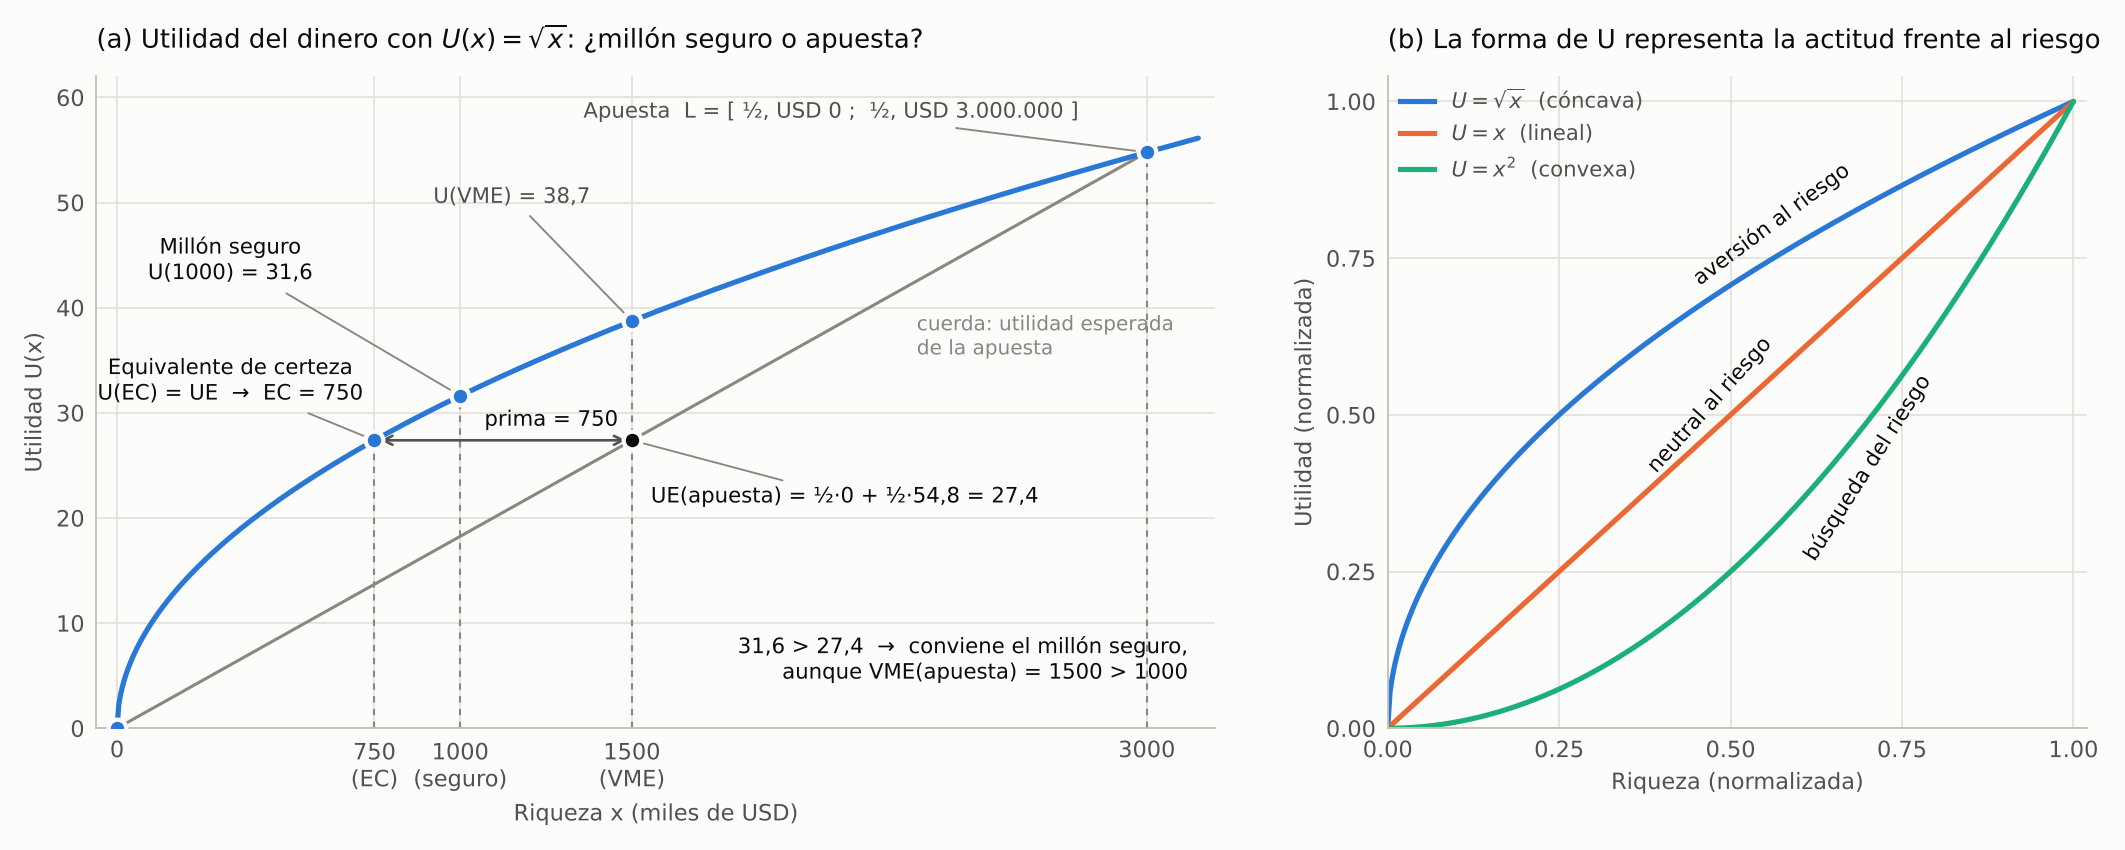
La **forma** de la curva de utilidad representa la **actitud del agente frente al riesgo**:

| Forma de $U$ | Actitud | Condición para una lotería $L$ |
|---|---|---|
| Cóncava | Aversión al riesgo | $U(L) < U(S_{\text{VME}(L)})$ |
| Lineal | Neutral al riesgo | $U(L) = U(S_{\text{VME}(L)})$ |
| Convexa | Búsqueda del riesgo | $U(L) > U(S_{\text{VME}(L)})$ |

Grayson (1960) midió empíricamente que la utilidad del dinero de las personas es aproximadamente proporcional a su logaritmo, como ya había propuesto Bernoulli (1738). Además, para montos chicos frente a la riqueza total cualquier curva es casi lineal; por eso, en decisiones con poco en juego, es razonable usar directamente el valor monetario esperado.

#### 7. Utilidad con varios atributos

En problemas reales un resultado se describe con varios atributos $\mathbf{x} = (x_1, \dots, x_n)$: para ubicar un aeropuerto importan el costo, el ruido y la siniestralidad; para un vehículo autónomo, el tiempo de viaje, la seguridad y el consumo. La función de utilidad $U(x_1, \dots, x_n)$ representa entonces **cuánto de un atributo está dispuesto a sacrificar el agente para ganar en otro**. Si los atributos son **mutuamente independientes en cuanto a preferencias**, se puede usar una **función de valor aditiva**:

$$V(x_1, \dots, x_n) = \sum_{i=1}^{n} V_i(x_i)$$

donde cada $V_i$ depende de un solo atributo. Bajo incertidumbre, si se cumple la independencia mutua de utilidad, la forma correspondiente es multiplicativa.

#### 8. Dónde aparece en IA

- **Agentes basados en utilidad (teoría de la decisión):** eligen la acción de mayor utilidad esperada (principio de MUE).
- **Decisiones secuenciales (procesos de decisión de Markov):** la utilidad de un estado es la suma esperada de recompensas descontadas que se obtienen a partir de él, $U^{\pi}(s) = E\left[\sum_{t=0}^{\infty} \gamma^{t} R(s_t) \mid \pi, s_0 = s\right]$; la iteración de valores calcula esa función.
- **Medicina y seguridad:** se usan escalas de utilidad como los AVAC (años de vida ajustados por calidad) y la micromortalidad (una probabilidad de muerte de 1 en un millón).
- **Sistemas expertos basados en la teoría de la decisión:** combinan la probabilidad de cada diagnóstico con la utilidad de cada resultado para recomendar la acción de mayor utilidad esperada.

#### 9. Aclaración: es un modelo normativo

La teoría de la utilidad describe cómo **debería** decidir un agente racional, no necesariamente cómo deciden las personas. Por ejemplo, en la paradoja de Allais la mayoría prefiere *100 % de ganar USD 3.000* antes que *80 % de ganar USD 4.000*, pero prefiere *20 % de ganar USD 4.000* antes que *25 % de ganar USD 3.000*. Con $U(0) = 0$, la primera elección implica $U(3000) > 0{,}8\,U(4000)$ y la segunda (multiplicando por 4) $0{,}8\,U(4000) > U(3000)$: ninguna función de utilidad puede explicar las dos elecciones. Para un agente artificial esto no es un problema, porque su función de utilidad la define el diseñador.

#### En síntesis

Una función de utilidad representa **qué quiere el agente y cuánto lo quiere**:

1. Ordena los estados según las preferencias del agente: $U(A) > U(B) \iff A \succ B$.
2. Combinada con las probabilidades, le permite elegir la mejor acción bajo incertidumbre: $A^{*} = \arg\max_{A} \text{UE}(A \mid E)$.
3. Su forma (cóncava, lineal o convexa) codifica la actitud frente al riesgo.
4. Con varios atributos, codifica los compromisos entre objetivos en conflicto.

Su existencia está garantizada por los axiomas de la teoría de la utilidad, y es la base del resto de los temas del práctico: la toma de decisiones basada en utilidad, el valor de la información y los sistemas expertos basados en la teoría de la decisión.

2. Respondan las siguientes preguntas. Cada respuesta corresponde a un axioma de la utilidad, indique cuál se relaciona con cada pregunta y dé una breve explicación de lo que dice el axioma.

&emsp;&emsp;2.1 ¿Qué color prefieren?

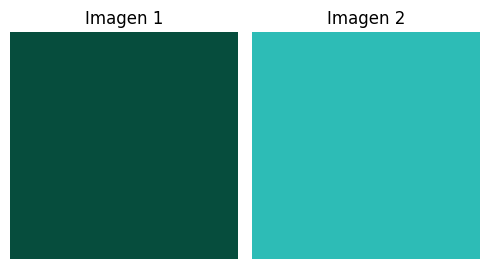

In [6]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URLs directas de Google Drive
url1 = "https://drive.google.com/uc?export=view&id=1aofwvS7bUVmKS6MlTcpL2ZgVa9JuGJex"
url2 = "https://drive.google.com/uc?export=view&id=1-htp7twx9y5-GpzMUXl9hk-X3kV-BVz6"

# Función para descargar y redimensionar imagen
def load_and_resize(url, size=(10, 10)):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = img.resize(size, Image.Resampling.LANCZOS)  # redimensionar a 150x150
    return img

# Cargar imágenes
img1 = load_and_resize(url1)
img2 = load_and_resize(url2)

# Crear figura con 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(5, 5))

# Mostrar primera imagen
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title("Color 1")

# Mostrar segunda imagen
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title("Color 2")

plt.tight_layout()
plt.show()

Axioma de Completitud o Totalidad. Establece que ante 2 alternativas el agente siempre puede compararlas y definir su postura. Dicho de otra manera, el agente siempre peude establecer una relación de preferencia entre ambos estados, ya sea la preferencia del color 1 por sobre el color 2 o viceversa.

&emsp;&emsp;2.2 Entre sacar un 10 o un 7 en un parcial, ¿qué prefieren? ¿Y entre el 7 y desaprobar?

Axioma de Transitividad. Establece la coherencia en el orden de preferencias, si se prefiere el 10 por sobre el 7, y el 7 por sobre desaprobar entonces obligatoriamente se prefiere el 10 por sobre desaprobar. La transitividad previene contradicciones lógicas en las elecciones del agente.


&emsp;&emsp;2.3 Imagínense que hacen una apuesta de $100 jugando al cara o cruz, si pudieran trucar la moneda para que ustedes ganaran un porcentaje *p* de las veces, ¿en qué valor configurarían *p*?

Axioma de Monotonicidad. Establece que si se prefiere un resultado A sobre otro resultado B, siempre el agente va a preferir estrictamente aquella opcion que le da mayor probabilidad al resultado preferido A.
En el caso específico de la pregunta, el agente va a preferir ganar a perder por lo que va a configurar la probabilidad p al máximo posible.


&emsp;&emsp;2.4 En una feria hay dos juegos: uno en el que el premio son $100 y otro en el que el premio es una piedra, ambos con una probabilidad *p* de ganar al juego. ¿A qué juego prefieren jugar?

Axioma de Sustituibilidad. Establece que si un agente prefiere un resultado (la plata por sobre la piedra) entonces hay una preferencia estricta del juego que ofrece el resultado buscado por sobre la que no lo ofrece.


&emsp;&emsp;2.5 En un casino hay dos juegos y en ambos el premio son $1000. El primer juego se gana cuando se tira una moneda y sale cara y el segundo juego se gana cuando sale 6 en un dado. ¿A qué juego prefieren jugar?

Axioma de Monotonicidad. Establece que si se prefiere un resultado A sobre otro resultado B, siempre el agente va a preferir estrictamente aquella opcion que le da mayor probabilidad al resultado preferido A.
En este caso la moneda ofrece un 50% de probabilidad de ganar mientras que el dado ofrece solo 16.7% por lo que el agente siempre va a elegir el juego de la moneda.


&emsp;&emsp;2.6 Supongamos que quiere postularse a una beca. Primero, existe un 60% de probabilidad de que le llamen para una entrevista. Si no le llaman, entonces hay un 20% de probabilidad de que le ofrezcan participar en un curso online ¿Cuál es la probabilidad total de cada evento (recibir la beca, recibir el curso o no recibir nada)?

Axioma de Descomponibilidad. Establece que una lotería secuencial en varias etapas es equivalente a una loteria simple.
-Probabilidad de recibir la beca: P(B)=0.6
-Probabilidad de NO ser llamado para la entrevista: P(NE)=1-0.6=0.4
-Probabilidad de recibir curso online: P(C)=P(NE) * 0.2=0.4 * 0.2=0.08
-Probabilidad de NO recibir nada(probabilidad de que no hagan la entrevista y que no den el curso): P(N)=P(NE) * P(NC)=P(NE) * (1-0.2)=0.4 * 0.8=0.32

3. Los boletos de una lotería cuestan un dólar. Hay dos juegos posibles con distintos premios: uno de 10 dólares con una probabilidad de uno entre 50 y otro de 1.000.000 dólares con una probabilidad de uno entre 2.000.000.

&emsp;&emsp;3.1 ¿Cuál es el valor monetario esperado del boleto de lotería?

**Boleto / Juego 1 (Premio de 10):**
- **Premio:**  10 con probabilidad $P_1 = \frac{1}{50} = 0.02$.
- **Sin premio:**  0 con probabilidad $P_0 = 1 - 0.02 = 0.98$.
- **Costo:** 1.

1. **VME Bruto (Boleto 1):**
   $$
   \text{VME}_{\text{bruto,1}} = (10 \times 0.02) + (0 \times 0.98) = \mathbf{0.20\text{ dólares}} \quad (20\text{ centavos})
   $$

2. **VME Neto (Boleto 1):**
   $$
   \text{VME}_{\text{neto,1}} = 0.20 - 1.00 = \mathbf{-0.80\text{ dólares}} \quad (-80\text{ centavos})
   $$

**Boleto / Juego 2 (Premio de 1.000.000):**
- **Premio:** 1.000.000 con probabilidad $P_2 = \frac{1}{2.000.000} = 0.0000005 = 5 \times 10^{-7}$.
- **Sin premio:** 0 con probabilidad $P_0 = 1 - 0.0000005 = 0.9999995$.
- **Costo:** 1.

1. **VME Bruto (Boleto 2):**
   $$
   \text{VME}_{\text{bruto,2}} = (1.000.000 \times 5 \times 10^{-7}) + (0 \times 0.9999995) = \mathbf{0.50\text{ dólares}} \quad (50\text{ centavos})
   $$

2. **VME Neto (Boleto 2):**
   $$
   \text{VME}_{\text{neto,2}} = 0.50 - 1.00 = \mathbf{-0.50\text{ dólares}} \quad (-50\text{ centavos})
   $$

**Conclusion:**
- **Boleto 1 (10):** VME bruto = **0.20**, VME neto = **-0.80** (pérdida esperada de 80 centavos por boleto).
- **Boleto 2 (1.000.000):** VME bruto = **0.50**, VME neto = **-0.50** (pérdida esperada de 50 centavos por boleto).



&emsp;&emsp;3.2 ¿Cuándo es razonable comprar un boleto?

Aplicando el Principio de Máxima Utilidad Esperada (MUE) para cada uno por separado (con riqueza actual $k$ y estado base $U(S_k) = 0$):

**A. Boleto 1 (Juego de \$10):**
$$
\text{UE}(\text{Boleto 1}) = 0.98 \cdot U(S_{k-1}) + 0.02 \cdot U(S_{k+9})
$$

**Análisis:** Ganar \$10 netos ($S_{k+9}$) no genera un cambio significativo en la vida de casi ninguna persona. La pérdida probable de \$1 pesa más que la ganancia de \$10. Por lo tanto, **casi NUNCA es racional comprar el Boleto 1**.

**B. Boleto 2 (Juego de \$1.000.000):**
$$
\text{UE}(\text{Boleto 2}) = 0.9999995 \cdot U(S_{k-1}) + (5 \times 10^{-7}) \cdot U(S_{k+999.999})
$$

**Análisis:** Basado en lo calculos y analizando que la probabilidad de ganar es muy baja, no le conviene a nadie jugar. 

4. Hay que reparar una máquina averiada y el mecánico diagnostica que si la avería es leve la reparación costará \$300, pero si es grave costará \$1.200. La probabilidad de que la avería sea grave es 2/3. También se ofrece la alternativa de comprar una máquina
usada por \$600. Qué decisión se tomará si:

&emsp;&emsp;4.1 La función de utilidad fuese la mostrada por el agente rojo.

&emsp;&emsp;4.2 La función de utilidad fuese la mostrada por el agente verde.

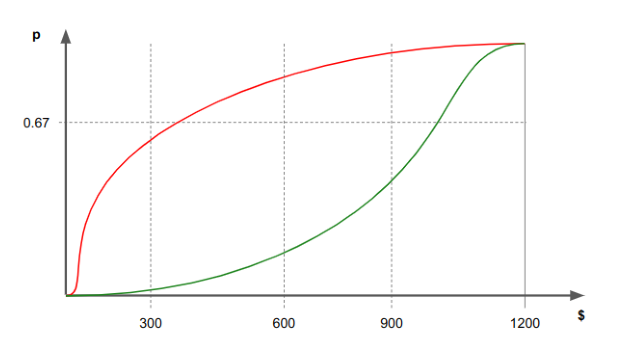

In [7]:
url = "https://drive.google.com/uc?export=view&id=1vNTlLArEhsxTOIvgs-NJ7NcE0B0JPJcw"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar con figura más grande
plt.figure(figsize=(img.width / 80, img.height / 80))  # ajustá el divisor según densidad deseada
plt.imshow(img)
plt.axis('off')
plt.show()

- Si La función de utilidad fuese la mostrada por el agente rojo, el agente preferiría hacer la reparación

    - Como el precio de la "maquina usada" sería 600, el agente rojo estaría dispuesto a realizar la reparación con una probabilidad de que la reparación sea grave mas grande que la planteada de 0,67 (aparenta ser 0,8 el umbral donde no acepta la reparación)

    - Este agente, para la misma probabilidad de 0,67, siempre preferiría realizar la reparación mientras que el precio de la usada sea mayor a algún valor superior a 350


- Si La función de utilidad fuese la mostrada por el agente Verde, el agente preferiría comprar la maquina usada

    - Como el precio de la "maquina usada" sería 600, el agente verde estaría dispuesto a realizar la reparación sólo si la probabilidad de que la reparación sea grave fuera mas chica que la planteada (aparenta ser 0,3 el umbral)

    - Este agente, para la misma probabilidad de 0,67, siempre preferiría realizar la reparación mientras que el precio de la usada sea mayor a algún valor superior a 1000

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

5. En unos laboratorios de un hospital se está investigando sobre una sustancia para la curación de una determinada enfermedad. Dicha sustancia ha sido inyectada en varias cobayas enfermas para verificar sus efectos. Los resultados de las pruebas realizadas se sintetizan en la siguiente tabla:

<table><tr><td><b>Estado de la enfermedad</td><td><b>Concentración de la sustancia</td><td><b>Número de dosis</td><td><b>Condición física</td><td><b>Efecto</td></tr>

<tr><td>Incipiente</td><td>75</td><td>70</td><td>Fuerte</td><td>Curación</td></tr>

<tr><td>Incipiente</td><td>80</td><td>90</td><td>Fuerte</td><td>Defunción</td></tr>

<tr><td>Incipiente</td><td>85</td><td>85</td><td>Débil</td><td>Defunción</td></tr>

<tr><td>Incipiente</td><td>62</td><td>95</td><td>Débil</td><td>Defunción</td></tr>

<tr><td>Incipiente</td><td>79</td><td>70</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Avanzado</td><td>72</td><td>90</td><td>Fuerte</td><td>Curación</td></tr>

<tr><td>Avanzado</td><td>83</td><td>78</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Avanzado</td><td>64</td><td>66</td><td>Fuerte</td><td>Curación</td></tr>

<tr><td>Avanzado</td><td>81</td><td>75</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Terminal</td><td>71</td><td>80</td><td>Fuerte</td><td>Defunción</td></tr>

<tr><td>Terminal</td><td>65</td><td>70</td><td>Fuerte</td><td>Defunción</td></tr>

<tr><td>Terminal</td><td>75</td><td>80</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Terminal</td><td>68</td><td>80</td><td>Débil</td><td>Curación</td></tr>

<tr><td>Terminal</td><td>70</td><td>96</td><td>Débil</td><td>Curación</td></tr></table>

Determine las reglas que rigen las condiciones en las que se ha de administrar una sustancia e implemente un sistema experto en CLIPS que determine si un sujeto resultará curado o no.

## Prompt  Utilizado
Actúa como un **ingeniero especializado en Inteligencia Artificial, Sistemas Expertos, lógica de producción y programación en CLIPS**, con nivel de conocimientos equivalente al de un estudiante avanzado de Ingeniería.

Necesito resolver el siguiente ejercicio académico:

---

## ENUNCIADO

En unos laboratorios de un hospital se está investigando sobre una sustancia para la curación de una determinada enfermedad. La sustancia ha sido inyectada en varias cobayas enfermas para verificar sus efectos. Los resultados son:

| Estado de la enfermedad | Concentración de la sustancia | Número de dosis | Condición física | Efecto |
|---|---:|---:|---|---|
| Incipiente | 75 | 70 | Fuerte | Curación |
| Incipiente | 80 | 90 | Fuerte | Defunción |
| Incipiente | 85 | 85 | Débil | Defunción |
| Incipiente | 62 | 95 | Débil | Defunción |
| Incipiente | 79 | 70 | Débil | Curación |
| Avanzado | 72 | 90 | Fuerte | Curación |
| Avanzado | 83 | 78 | Débil | Curación |
| Avanzado | 64 | 66 | Fuerte | Curación |
| Avanzado | 81 | 75 | Débil | Curación |
| Terminal | 71 | 80 | Fuerte | Defunción |
| Terminal | 65 | 70 | Fuerte | Defunción |
| Terminal | 75 | 80 | Débil | Curación |
| Terminal | 68 | 80 | Débil | Curación |
| Terminal | 70 | 96 | Débil | Curación |

La consigna es:

**“Determine las reglas que rigen las condiciones en las que se ha de administrar una sustancia e implemente un sistema experto en CLIPS que determine si un sujeto resultará curado o no.”**

---

## OBJETIVO

Resuelve el ejercicio de manera completa, clara y académica. No quiero solamente el código: necesito que expliques cómo se obtienen las reglas a partir de la tabla.

### 1. Análisis de los datos

Analiza las 14 observaciones e identifica patrones entre:

- Estado de la enfermedad.
- Concentración.
- Número de dosis.
- Condición física.
- Efecto final.

Determina qué variables parecen ser relevantes para decidir entre **Curación** y **Defunción**.

Presta especial atención a las variables numéricas y determina si existen **umbrales o rangos** que permitan establecer reglas.

No inventes valores arbitrarios: los límites utilizados deben surgir de los datos disponibles.

---

### 2. Obtención de las reglas

Obtén un conjunto de reglas **simple, interpretable y consistente con la totalidad de la tabla**.

Para cada regla indica:

- Condiciones que deben cumplirse.
- Resultado obtenido.
- Filas de la tabla que justifican la regla.
- Si existen excepciones o casos ambiguos.

Comprueba que las reglas propuestas permitan clasificar correctamente las **14 observaciones**.

Si existen varias soluciones posibles debido al pequeño tamaño del conjunto de datos, indícalo explícitamente y selecciona el conjunto de reglas más sencillo y justificable.

No presentes una regla como única verdad si los datos permiten varias hipótesis.

---

### 3. Representación como sistema experto

Diseña el sistema experto utilizando la estructura clásica:

**HECHOS → REGLAS → CONCLUSIÓN**

Explica qué hechos representarán:

- Estado de enfermedad.
- Concentración.
- Número de dosis.
- Condición física.

Y qué hechos representarán las conclusiones:

- Curación.
- Defunción.

---

### 4. Implementación en CLIPS

Genera un programa CLIPS completo y ejecutable.

El programa debe permitir ingresar los datos de un nuevo sujeto y determinar automáticamente si el resultado esperado es:

- `curacion`
- `defuncion`

Utiliza una estructura clara mediante `deftemplate`, `deffacts` y/o reglas `defrule`, según corresponda.

El código debe estar correctamente estructurado y comentado.

Evita soluciones excesivamente complicadas. Prioriza que el código sea comprensible para un estudiante de Ingeniería.

---

### 5. Inferencia

Explica detalladamente cómo funciona el mecanismo de inferencia de CLIPS en este problema.

Muestra:

1. Qué hechos iniciales se cargan.
2. Qué regla se activa.
3. Qué conclusión se agrega a la memoria de trabajo.
4. Cómo se obtiene el resultado final.

Explica también qué ocurre si ninguna regla puede clasificar al sujeto.

---

### 6. Pruebas del programa

Incluye al menos estos casos de prueba:

- Un sujeto que debería resultar en `curacion`.
- Un sujeto que debería resultar en `defuncion`.
- Un caso de cada estado de enfermedad.
- Un caso cercano a los límites numéricos encontrados.

Para cada caso muestra:

**Entrada → reglas activadas → conclusión**

Además, realiza una comprobación conceptual de las 14 filas originales para demostrar que las reglas reproducen los resultados de la tabla.

---

### 7. Árbol de decisión

Antes de escribir las reglas CLIPS, intenta representar el problema mediante un **árbol de decisión**.

Indica cuál sería la variable más conveniente para comenzar la clasificación y explica por qué.

Si la utilización de un árbol de decisión como ID3/C4.5 ayuda a obtener las reglas, puedes utilizar ese enfoque, pero no es obligatorio. Lo importante es que las reglas finales sean comprensibles y estén justificadas por los datos.

---

### 8. Ambigüedad y generalización

Explica una cuestión importante de aprendizaje automático:

La tabla contiene solamente 14 ejemplos. Por lo tanto, las reglas obtenidas representan una **hipótesis basada en esos datos** y no necesariamente una ley médica general.

Explica brevemente la diferencia entre:

- Memorizar los ejemplos.
- Inferir reglas generales a partir de los ejemplos.

Indica también si las reglas obtenidas podrían clasificar correctamente sujetos nuevos que no aparezcan en la tabla.

---

## FORMATO DE LA RESPUESTA

Organiza la respuesta exactamente en este orden:

### A. Análisis de la tabla

### B. Identificación de patrones

### C. Reglas obtenidas

Presenta las reglas también en lenguaje natural.

Por ejemplo:

> SI condición 1 Y condición 2 ENTONCES Curación.

### D. Árbol de decisión

### E. Código completo en CLIPS

### F. Ejemplos de ejecución

### G. Conclusión

---

## REQUISITOS IMPORTANTES

1. No te limites a entregar código.
2. No inventes datos que no estén en la tabla.
3. Las reglas deben estar justificadas a partir de las observaciones.
4. Debes comprobar que no exista una contradicción entre las reglas.
5. Debes explicar claramente los umbrales utilizados para concentración y número de dosis.
6. Si hay varias formas de construir las reglas, explica la alternativa y por qué eliges una determinada estructura.
7. El código debe ser compatible con **CLIPS estándar**.
8. No uses pseudocódigo en lugar de CLIPS.
9. Utiliza nombres de hechos y reglas claros y en español cuando sea posible.
10. El resultado debe tener un nivel académico apropiado para un estudiante de Ingeniería y ser apto para incluirse en un informe o trabajo práctico.
11. Diferencia claramente entre las **reglas inferidas de los datos** y las decisiones de implementación en CLIPS.
12. No atribuyas validez médica real a estas reglas: trátalas exclusivamente como un ejercicio académico de sistemas expertos.

Antes de presentar el código, muestra primero cómo llegaste matemática y lógicamente a las reglas.

### A. Análisis de la tabla

La tabla contiene 14 observaciones. Para cada cobaya se conocen cuatro atributos de entrada:

- Estado de la enfermedad.

- Concentración de la sustancia.

- Número de dosis.

- Condición física.

Y una variable de salida:

- Efecto: Curación o Defunción.

La primera tarea consiste en determinar qué atributos contienen información útil para separar ambos resultados.

### A.1. Distribución general de los resultados

De las 14 observaciones:

- 9 corresponden a Curación.

- 5 corresponden a Defunción.

Por tanto, existe una distribución:

$
P(Curación)=\frac{9}{14}
$

$
P(Defunción)=\frac{5}{14}
$

La entropía inicial del conjunto es aproximadamente:

$
H(S)=
-\frac{9}{14}\log_2\left(\frac{9}{14}\right)
-\frac{5}{14}\log_2\left(\frac{5}{14}\right)
$

$
\boxed{H(S)\approx 0.9403}
$

Este valor indica que inicialmente existe una mezcla de ambas clases.

### A.2. Análisis según el estado de la enfermedad

Separando los casos por estado:

#### Incipiente

Hay 5 observaciones:

| Concentración | Dosis | Condición | Resultado |
|---|---|---|---|
| 75 | 70 | Fuerte | Curación |
|80|90|Fuerte|Defunción|
|85|85|Débil|Defunción|
|62|95|Débil|Defunción|
|79|70|Débil|Curación|

Distribución:

- 2 curaciones.

- 3 defunciones.

La entropía es:

$
H(I)=
-\frac25\log_2\frac25-\frac35\log_2\frac35
\approx0.971
$

#### Avanzado

Hay 4 observaciones:

|Concentración|Dosis|Condición|Resultado|
|---|---|---|---|
|72|90|Fuerte|Curación|
|83|78|Débil|Curación|
|64|66|Fuerte|Curación|
|81|75|Débil|Curación|

Aquí:

$
4\ Curaciones,\qquad 0\ Defunciones
$

Por tanto:

$
\boxed{H(A)=0}
$

Todos los ejemplos avanzados terminan en curación.

#### Terminal

Hay 5 observaciones:

|Concentración|Dosis|Condición|Resultado|
|---|---|---|---|
|71|80|Fuerte|Defunción|
|65|70|Fuerte|Defunción|
|75|80|Débil|Curación|
|68|80|Débil|Curación|
|70|96|Débil|Curación|

Distribución:

3 curaciones.

2 defunciones.

Por tanto:

$
H(T)\approx0.971
$

### A.3. Información aportada por el estado de la enfermedad

El estado de la enfermedad produce grupos mucho más homogéneos que las demás variables.

La entropía posterior es:

$
H(S|Estado)=
\frac5{14}(0.971)+
\frac4{14}(0)+
\frac5{14}(0.971)
$

$
H(S|Estado)\approx0.6935
$

Por tanto, la ganancia de información es:

$
IG(Estado)=0.9403-0.6935
$

$
\boxed{IG(Estado)\approx0.2467}
$

Esto hace que Estado de la enfermedad sea una candidata natural para comenzar el árbol de decisión.

### B. Identificación de patrones

### B.1. Patrón principal: estado avanzado

Las cuatro cobayas con enfermedad avanzada presentan curación:

$
Avanzado\Rightarrow Curación
$

Los valores de concentración y dosis varían considerablemente:

- Concentración: 64, 72, 81 y 83.

- Dosis: 66, 75, 78 y 90.

- Condición: fuerte y débil.

Por lo tanto, no es necesario establecer umbrales de concentración o dosis para los casos avanzados.

La regla obtenida es:

-- SI el estado de la enfermedad es Avanzado, ENTONCES Curación.

### B.2. Patrón en enfermedad terminal

En este grupo aparece una separación perfectamente clara mediante la condición física:

|Condición|Casos|Resultado|
|---|---|---|
|Fuerte|2|Defunción|
|Débil|3|Curación|

Por lo tanto:

-- SI el estado es Terminal Y la condición física es Débil, ENTONCES Curación.

y

--SI el estado es Terminal Y la condición física es Fuerte, ENTONCES Defunción.

La concentración y el número de dosis no son necesarios para separar los casos terminales.

Por ejemplo, la dosis 80 aparece tanto en:

- Terminal + Fuerte → Defunción.

- Terminal + Débil → Curación.

Por lo tanto, la dosis por sí sola no permite decidir el resultado en estado terminal.

### B.3. Patrón en enfermedad incipiente

Aquí la condición física tampoco separa las clases:

- Fuerte aparece tanto en Curación como en Defunción.

- Débil aparece tanto en Curación como en Defunción.

La concentración tampoco produce un umbral simple.

Los datos ordenados por concentración son:

|Concentración|Resultado|
|---|---|
|62|Defunción|
|75|Curación|
|79|Curación|
|80|Defunción|
|85|Defunción|

Esto demuestra que una simple regla del tipo:

$
Concentración < X \Rightarrow Curación
$

o

$
Concentración > X \Rightarrow Defunción
$

no puede clasificar correctamente los cinco casos.

El valor 62 produce defunción, mientras que 75 y 79 producen curación.

### B.4. Número de dosis en enfermedad incipiente

Aquí sí aparece una separación perfecta.

Los datos son:

|Dosis|Resultado|
|---|---|
|70|Curación|
|70|Curación|
|85|Defunción|
|90|Defunción|
|95|Defunción|

Existe una frontera entre:

$
70\quad\text{y}\quad85
$

Todas las curaciones tienen:

$
dosis=70
$

y todas las defunciones tienen:

$
dosis\geq85
$

Entre 70 y 85 no existen observaciones.

Por eso, matemáticamente no puede afirmarse que el verdadero límite sea exactamente 70, 77.5, 75 u otro valor intermedio.

Sin embargo, para construir una regla de clasificación para sujetos nuevos, una práctica habitual es colocar el umbral en el punto medio entre la mayor dosis de curación y la menor dosis de defunción:

$
D_{umbral}=
\frac{70+85}{2}
$

$
\boxed{D_{umbral}=77.5}
$

Por tanto, se adopta como decisión de implementación:

$
Dosis\leq77.5\Rightarrow Curación
$

$
Dosis>77.5\Rightarrow Defunción
$

Es importante remarcar que 77.5 no es un dato médico observado. Es un umbral matemáticamente derivado de los ejemplos disponibles.

Cualquier umbral dentro del intervalo:

$
70<t<85
$

reproduciría igualmente las cinco observaciones incipientes.

Por eso existe una familia de hipótesis posibles, y 77.5 se elige solamente como separación central y simétrica.

### C. Reglas obtenidas

El conjunto final de reglas es el siguiente.

#### Regla R1

- SI Estado = Avanzado
- ENTONCES Resultado = Curación.

Justificación: las cuatro observaciones avanzadas terminan en curación.

Casos utilizados:

$
6,\ 7,\ 8,\ 9
$

#### Regla R2

- SI Estado = Terminal Y Condición física = Débil
- ENTONCES Resultado = Curación.

Casos:

$
12,\ 13,\ 14
$

#### Regla R3

- SI Estado = Terminal Y Condición física = Fuerte
- ENTONCES Resultado = Defunción.

Casos:

$
10,\ 11
$

#### Regla R4

- SI Estado = Incipiente Y Número de dosis $(\leq77.5)$
- ENTONCES Resultado = Curación.

Los dos casos de curación incipientes poseen 70 dosis:

$
70\leq77.5
$

Casos:

$
1,\ 5
$

#### Regla R5

- SI Estado = Incipiente Y Número de dosis (>77.5)
- ENTONCES Resultado = Defunción.

Casos:

$
2,\ 3,\ 4
$

con dosis:

$
90,\ 85,\ 95
$

respectivamente.

#### C.1. ¿Qué ocurrió con la concentración?

La concentración se incorpora al sistema como dato de entrada porque forma parte del problema, pero no aparece en las reglas finales.

Esto es una decisión importante:

Una variable puede formar parte de los hechos del sistema experto y, sin embargo, no ser necesaria en las reglas de clasificación.

En este conjunto particular de datos, la concentración no mejora la clasificación cuando ya se han considerado estado, condición física y dosis.

#### C.2. ¿Existen contradicciones entre las reglas?

No.

Las reglas están construidas para que cada sujeto caiga en una única rama:

- avanzado

- terminal + fuerte

- terminal + debil

- incipiente + dosis <= 77.5

- incipiente + dosis > 77.5

Estas condiciones son mutuamente excluyentes.

Por ejemplo, un sujeto no puede ser simultáneamente:

$
terminal\land fuerte
$

y

$
terminal\land debil
$

ni puede cumplir simultáneamente:

$
dosis\leq77.5
$

y

$
dosis>77.5
$

Por lo tanto, no se generan dos conclusiones contradictorias para el mismo sujeto.

### D. Árbol de decisión

El árbol puede representarse como:

                    [Estado]
                  /    |      \
                 /     |       \
          Incipiente Avanzado  Terminal
              |          |         |
           [Dosis]    Curación [Condición física]
            /   \                /          \
           /     \              /            \
      <= 77.5    > 77.5     Fuerte          Débil
          |          |          |               |
      Curación   Defunción   Defunción       Curación

### D.1. ¿Por qué comenzar por Estado?

Porque separa de manera natural el problema:

*Estado = Avanzado

No es necesario seguir preguntando nada:

$
Avanzado\rightarrow Curación
$

*Estado = Terminal

La variable relevante es la condición física:

$
Fuerte\rightarrow Defunción
$

$
Débil\rightarrow Curación
$

*Estado = Incipiente

La variable relevante es el número de dosis:

$
Dosis\leq77.5\rightarrow Curación
$

$
Dosis>77.5\rightarrow Defunción
$

El árbol produce hojas puras para todos los ejemplos de entrenamiento.

### D.2. ¿Podría utilizarse ID3/C4.5?

Sí.

La entropía inicial es:

$
H(S)\approx0.9403
$

y el atributo Estado presenta:

$
IG(Estado)\approx0.2467
$

mientras que la condición física, considerada globalmente, produce una ganancia mucho menor.

Además del criterio matemático, Estado tiene una ventaja conceptual: una vez separado el conjunto por estado, aparecen reglas muy simples y perfectamente interpretables.

Para las variables numéricas se podrían evaluar distintos puntos de corte. En este caso, para las observaciones incipientes, el intervalo entre 70 y 85 permite elegir:

$
\frac{70+85}{2}=77.5
$

como frontera de clasificación.

### E. Diseño del sistema experto

La arquitectura será:

$
\boxed{\text{HECHOS}\rightarrow\text{REGLAS}\rightarrow\text{CONCLUSIÓN}}
$

### F. Ejemplos de ejecución

### F.1. Caso de curación

Entrada:

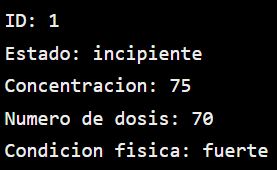

Se agraga:

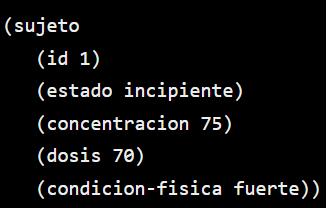

Por lo tanto se activa:

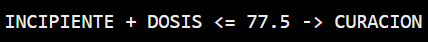

Conclusión:

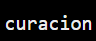

### F.2. Caso de defunción

Entrada:

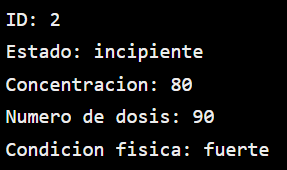

Se activa:

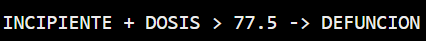

Conclusión:

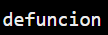

### F.3. Caso avanzado

Entrada:

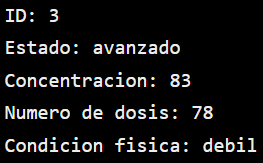

Se activa:

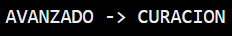

Conclusión:

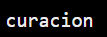

### F.4. Caso terminal y fuerte

Entrada:

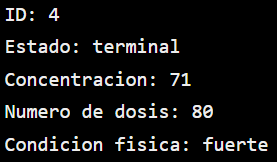

Se activa:

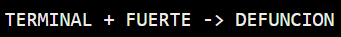

Conlcusión:

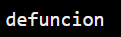

### F.5. Caso terminal y débil

Entrada:

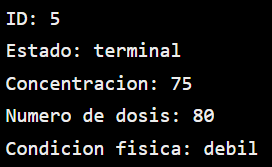

Se activa:

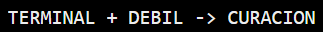

Colclusión:

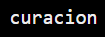

### F.6. Caso cercano al umbral

La frontera elegida es:

$
77.5
$

Dosis = 77.5

$
77.5\leq77.5
$

Resultado:



Dosis = 78

$
78>77.5
$

Resultado:



### F.7. Caso no clasificable

Supongamos:

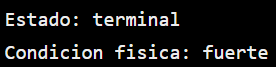

sí sería clasificable.

Pero si se introduce un valor fuera del conocimiento representado, por ejemplo un nuevo estado que no exista en la tabla —si se modificara el template para permitirlo— ninguna regla de clasificación coincidiría.

En ese caso se activa:

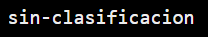

La idea es:

$
\text{Sin evidencia suficiente}
\Rightarrow
\text{No emitir una conclusión arbitraria}
$

### G. Conclusión

A partir de las 14 observaciones es posible construir un sistema experto pequeño y completamente interpretable.

La estructura obtenida es:

$
\boxed{
\text{Estado}
\rightarrow
\begin{cases}
\text{Avanzado} & \rightarrow \text{Curación} \\
\text{Terminal} & \rightarrow
\begin{cases}
\text{Fuerte} & \rightarrow \text{Defunción} \\
\text{Débil} & \rightarrow \text{Curación}
\end{cases} \\
\text{Incipiente} & \rightarrow
\begin{cases}
\text{Dosis} \leq 77.5 & \rightarrow \text{Curación} \\
\text{Dosis} > 77.5 & \rightarrow \text{Defunción}
\end{cases}
\end{cases}
}
$

La concentración se mantiene como dato de entrada, pero no resulta necesaria para las reglas finales porque no produce una separación limpia de los resultados.

La elección de 77.5 se obtiene matemáticamente como:

$
\frac{70+85}{2}=77.5
$

donde 70 es la mayor dosis observada asociada a curación en sujetos incipientes y 85 es la menor dosis observada asociada a defunción en ese mismo grupo.

Por lo tanto, debe distinguirse entre:

Regla directamente respaldada por los datos:

$
70\rightarrow Curación
$

$
85,90,95\rightarrow Defunción
$

y

regla de generalización utilizada en la implementación:

$
Dosis\leq77.5\rightarrow Curación
$

$
Dosis>77.5\rightarrow Defunción
$

El hecho de que existan únicamente 14 ejemplos implica que hay múltiples hipótesis compatibles con todos los datos. Por ejemplo, cualquier umbral comprendido entre 70 y 85 reproduciría exactamente los ejemplos incipientes.

Por eso, las reglas obtenidas no deben interpretarse como una ley médica. Son una hipótesis de conocimiento construida a partir de un conjunto pequeño de entrenamiento, adecuada para demostrar el funcionamiento de un sistema experto basado en reglas de producción.

Desde el punto de vista de Inteligencia Artificial, es fundamental diferenciar:

$
\boxed{\text{Memorizar ejemplos}\neq\text{Inferir reglas}}
$

Memorizar consistiría simplemente en guardar los 14 casos y buscar coincidencias exactas.

En cambio, el sistema desarrollado intenta generalizar:

“Para enfermedad incipiente, una dosis situada en la zona de curación conduce a la conclusión curacion, mientras que una dosis situada en la zona de defunción conduce a defuncion.”

Esa generalización permite clasificar sujetos nuevos, pero introduce incertidumbre en aquellos casos que no están representados de forma suficiente en los datos originales.

En consecuencia, el sistema propuesto consigue:

$
\boxed{\text{14/14 casos de entrenamiento correctamente clasificados}}
$

y proporciona una arquitectura clásica de sistema experto:

$
\boxed{\text{Hechos}\rightarrow\text{Motor de inferencia}\rightarrow\text{Reglas}\rightarrow\text{Conclusión}}
$

Todo ello debe entenderse exclusivamente como un ejercicio académico de Inteligencia Artificial y Sistemas Expertos, sin atribuir validez médica real a las reglas obtenidas.


### Código del Sistema Experto en Clips

In [ ]:
;===========================================================
; SISTEMA EXPERTO: CLASIFICACION DE RESULTADOS
; Ejercicio académico de lógica de producción en CLIPS
;===========================================================


;-----------------------------------------------------------
; 1. PLANTILLA DE LOS DATOS DE ENTRADA
;-----------------------------------------------------------

(deftemplate sujeto
   (slot id
      (type INTEGER))

   (slot estado
      (type SYMBOL)
      (allowed-values incipiente avanzado terminal))

   (slot concentracion
      (type NUMBER))

   (slot dosis
      (type NUMBER))

   (slot condicion-fisica
      (type SYMBOL)
      (allowed-values fuerte debil))
)

;-----------------------------------------------------------
; 2. PLANTILLA PARA LA CONCLUSION
;-----------------------------------------------------------

(deftemplate resultado
   (slot id
      (type INTEGER))

   (slot clasificacion
      (type SYMBOL)
      (allowed-values curacion defuncion sin-clasificacion))
)

;-----------------------------------------------------------
; 3. REGLA: ENFERMEDAD AVANZADA
;-----------------------------------------------------------

(defrule avanzado-curacion
   (declare (salience 100))
   ?s <- (sujeto
            (id ?id)
            (estado avanzado))
   (not (resultado (id ?id)))
   =>
   (assert
      (resultado
         (id ?id)
         (clasificacion curacion)))
   (printout t
      "Regla activada: AVANZADO -> CURACION" crlf)
)

;-----------------------------------------------------------
; 4. REGLA: TERMINAL + FUERTE
;-----------------------------------------------------------

(defrule terminal-fuerte-defuncion
   (declare (salience 100))
   ?s <- (sujeto
            (id ?id)
            (estado terminal)
            (condicion-fisica fuerte))
   (not (resultado (id ?id)))
   =>
   (assert
      (resultado
         (id ?id)
         (clasificacion defuncion)))
   (printout t
      "Regla activada: TERMINAL + FUERTE -> DEFUNCION" crlf)
)

;-----------------------------------------------------------
; 5. REGLA: TERMINAL + DEBIL
;-----------------------------------------------------------

(defrule terminal-debil-curacion
   (declare (salience 100))
   ?s <- (sujeto
            (id ?id)
            (estado terminal)
            (condicion-fisica debil))
   (not (resultado (id ?id)))
   =>
   (assert
      (resultado
         (id ?id)
         (clasificacion curacion)))
   (printout t
      "Regla activada: TERMINAL + DEBIL -> CURACION" crlf)
)

;-----------------------------------------------------------
; 6. REGLA: INCIPIENTE + DOSIS <= 77.5
;-----------------------------------------------------------

(defrule incipiente-curacion
   (declare (salience 100))
   ?s <- (sujeto
            (id ?id)
            (estado incipiente)
            (dosis ?d&:(<= ?d 77.5)))
   (not (resultado (id ?id)))
   =>
   (assert
      (resultado
         (id ?id)
         (clasificacion curacion)))
   (printout t
      "Regla activada: INCIPIENTE + DOSIS <= 77.5 -> CURACION"
      crlf)
)

;-----------------------------------------------------------
; 7. REGLA: INCIPIENTE + DOSIS > 77.5
;-----------------------------------------------------------

(defrule incipiente-defuncion
   (declare (salience 100))
   ?s <- (sujeto
            (id ?id)
            (estado incipiente)
            (dosis ?d&:(> ?d 77.5)))
   (not (resultado (id ?id)))
   =>
   (assert
      (resultado
         (id ?id)
         (clasificacion defuncion)))
   (printout t
      "Regla activada: INCIPIENTE + DOSIS > 77.5 -> DEFUNCION"
      crlf)
)

;-----------------------------------------------------------
; 8. REGLA DE SEGURIDAD
;-----------------------------------------------------------

(defrule sin-clasificacion
   (declare (salience -100))
   ?s <- (sujeto (id ?id))
   (not (resultado (id ?id)))
   =>
   (assert
      (resultado
         (id ?id)
         (clasificacion sin-clasificacion)))
   (printout t
      "No existe una regla aplicable para el sujeto." crlf)
)

;-----------------------------------------------------------
; 9. FUNCION PARA INGRESAR UN NUEVO SUJETO
;-----------------------------------------------------------

(deffunction ingresar-sujeto ()

   (printout t crlf
      "===== INGRESO DE NUEVO SUJETO =====" crlf)

   (printout t "ID: ")
   (bind ?id (read))

   (printout t
      "Estado (incipiente/avanzado/terminal): ")
   (bind ?estado (read))

   (printout t
      "Concentracion: ")
   (bind ?concentracion (read))

   (printout t
      "Numero de dosis: ")
   (bind ?dosis (read))

   (printout t
      "Condicion fisica (fuerte/debil): ")
   (bind ?condicion (read))

   (assert
      (sujeto
         (id ?id)
         (estado ?estado)
         (concentracion ?concentracion)
         (dosis ?dosis)
         (condicion-fisica ?condicion)))

   (run)

   (printout t
      "===== FIN DE LA INFERENCIA =====" crlf)
)

### Ejemplo de Ejecución
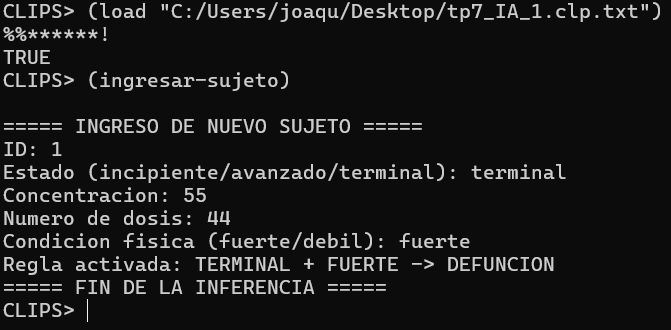


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)